# Entropy as a Curriculum Gate — Results Notebook

This notebook presents all experimental results for the paper.  
It loads pre-computed results and monitor logs, no training is re-run.

In [1]:
import os
os.environ["PYGAME_HIDE_SUPPORT_PROMPT"] = "1"
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")  # headless: no window, no SDL init noise

import contextlib

@contextlib.contextmanager
def _suppress_c_stderr():
    """Redirect C-level stderr (fd 2) to /dev/null — silences objc[...] lines
    that Python's warnings filter cannot catch."""
    import sys
    sys.stderr.flush()
    saved = os.dup(2)
    devnull = os.open(os.devnull, os.O_WRONLY)
    os.dup2(devnull, 2)
    os.close(devnull)
    try:
        yield
    finally:
        sys.stderr.flush()
        os.dup2(saved, 2)
        os.close(saved)

import json
import glob
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


## 1. Final Performance (Phase 3 — Hard)

In [2]:
with open('results_generalization.json') as f:
    gen = json.load(f)

LABELS = {
    'baseline': 'Baseline',
    'threshold': 'Threshold',
    'threshold_retreat': 'Threshold+Retreat',
    'continuous': 'Continuous',
    'success_rate': 'SuccessRate',
    'pcer': 'PCER',
    'pcer_low': 'PCER-low',
    'baseline_low': 'Baseline-low',
    'pcer_flat_low': 'PCER-flat-low',
    'threshold_3phase': 'Threshold-3ph',
    'threshold_retreat_3phase': 'Threshold+Retreat-3ph',
    'pcer_3phase': 'PCER-3ph',
    'pcer_flat_low_3phase': 'PCER-flat-low-3ph',
}

rows = []
for key, label in LABELS.items():
    if key in gen:
        rows.append({
            'Method': label,
            'Phase 1 (Easy)': gen[key]['1'],
            'Phase 2 (Medium)': gen[key]['2'],
            'Phase 3 (Hard)': gen[key]['3'],
        })

df = pd.DataFrame(rows).set_index('Method')
df.style.background_gradient(cmap='RdYlGn', vmin=50, vmax=280).format('{:.0f}')

,Phase 1 (Easy),Phase 2 (Medium),Phase 3 (Hard)
Method,,,
Baseline,181,207,225
Threshold,204,221,234
Threshold+Retreat,210,224,234
Continuous,190,205,216
SuccessRate,202,177,74
PCER,206,221,214
PCER-low,236,264,268
Baseline-low,236,248,264
PCER-flat-low,253,272,273


## 2. Generalization Heatmap

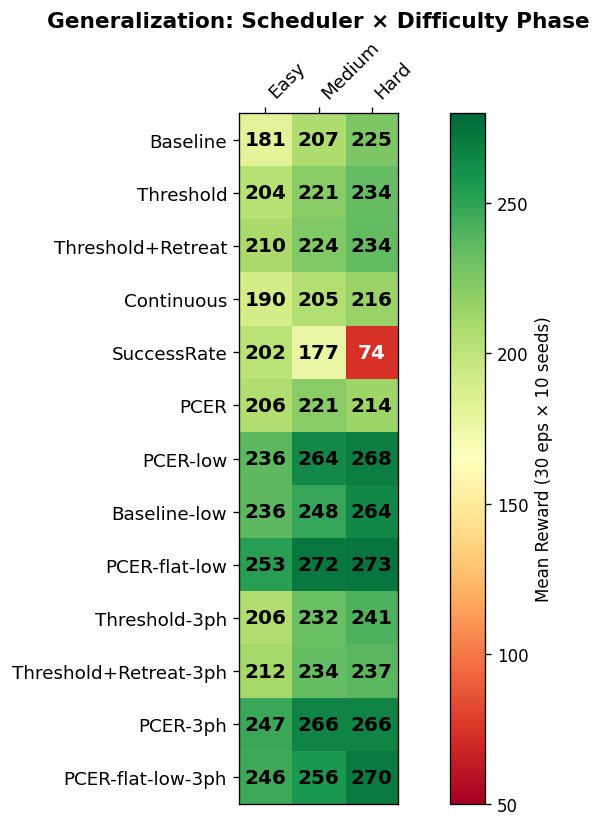

In [3]:
schedulers = list(gen.keys())
phases = [1, 2, 3]
phase_labels = ['Easy', 'Medium', 'Hard']
matrix = np.array([[gen[s][str(p)] for p in phases] for s in schedulers])

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=50, vmax=280)

ax.set_xticks(range(len(phases)))
ax.set_xticklabels(phase_labels, fontsize=11, rotation=45, ha='left')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_yticks(range(len(schedulers)))
ax.set_yticklabels([LABELS[s] for s in schedulers], fontsize=11)

for i in range(len(schedulers)):
    for j in range(len(phases)):
        val = matrix[i, j]
        color = 'black' if val > 150 else 'white'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Mean Reward (30 eps × 10 seeds)')
ax.set_title('Generalization: Scheduler × Difficulty Phase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Learning Curves

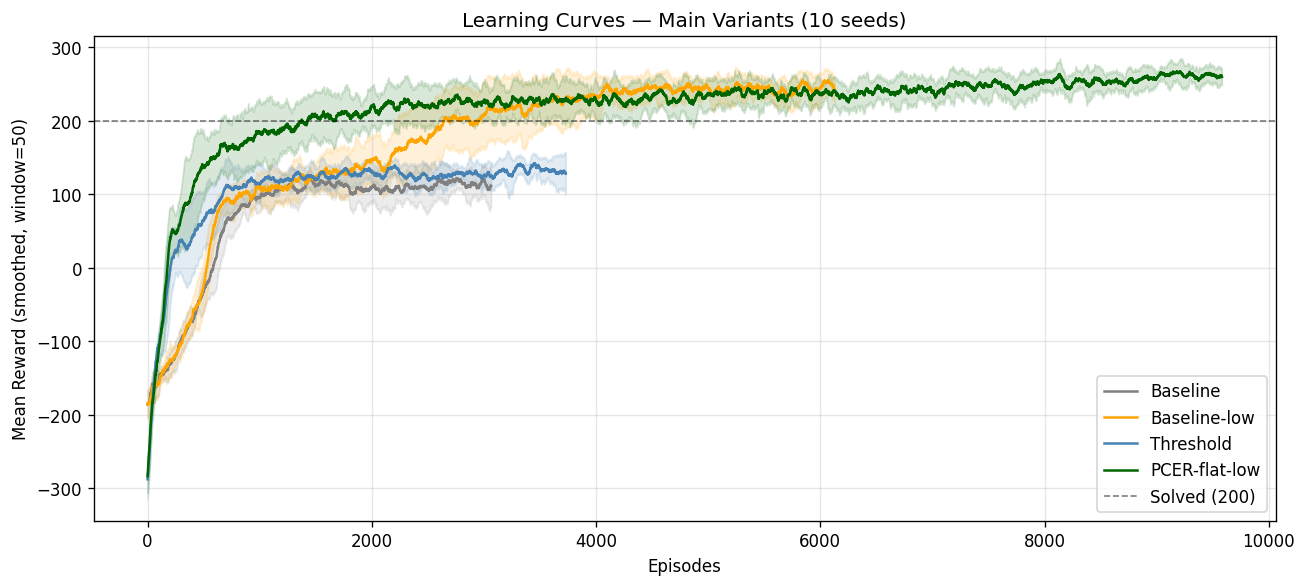

In [4]:
def smooth(y, window=50):
    return np.convolve(y, np.ones(window)/window, mode='valid')

def load_run(variant, seed, log_dir='runs'):
    path = os.path.join(log_dir, f'{variant}_seed{seed}.monitor.csv')
    df = pd.read_csv(path, skiprows=1)
    return df['l'].cumsum().to_numpy(), df['r'].to_numpy()

VARIANTS = [
    ('baseline',     'Baseline',      'gray'),
    ('baseline_low', 'Baseline-low',  'orange'),
    ('threshold',    'Threshold',     'steelblue'),
    ('pcer_flat_low','PCER-flat-low', 'darkgreen'),
]
SEEDS = list(range(10))
WINDOW = 50

fig, ax = plt.subplots(figsize=(11, 5))

for variant, label, color in VARIANTS:
    all_rewards, min_len = [], None
    for seed in SEEDS:
        try:
            _, y = load_run(variant, seed)
            s = smooth(y, WINDOW)
            all_rewards.append(s)
            min_len = len(s) if min_len is None else min(min_len, len(s))
        except FileNotFoundError:
            pass
    if not all_rewards:
        continue
    arr = np.array([r[:min_len] for r in all_rewards])
    mean, std = arr.mean(0), arr.std(0)
    ax.plot(mean, label=label, color=color)
    ax.fill_between(range(min_len), mean-std, mean+std, alpha=0.15, color=color)

ax.axhline(200, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Solved (200)')
ax.set_xlabel('Episodes')
ax.set_ylabel('Mean Reward (smoothed, window=50)')
ax.set_title('Learning Curves — Main Variants (10 seeds)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Statistical Analysis

In [5]:
# Per-seed statistics: one value per seed = mean over 30 deterministic Phase-3
# episodes (fixed eval seeds). Unit = seed, not episode (avoids pseudoreplication).
with _suppress_c_stderr():            # hide SDL/objc load-time noise
    from stable_baselines3 import PPO
    from envs.parametric_lunarlander import ParametricLunarLander

PHASE3 = {"gravity": -10.0, "wind_power": 15.0, "turbulence_power": 1.5}

def seed_mean_phase3(variant, seed, n_episodes=30):
    env = ParametricLunarLander(PHASE3, render_mode=None)
    with _suppress_c_stderr():
        model = PPO.load(f"checkpoints/{variant}_seed{seed}_final", env=env)
    rs = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=10_000 + ep)   # fixed eval layouts -> reproducible
        done = False; total = 0.0
        while not done:
            a, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(a); total += r; done = term or trunc
        rs.append(total)
    env.close()
    return float(np.mean(rs))

def per_seed_means(variant, seeds):
    seeds = [s for s in seeds if os.path.exists(f"checkpoints/{variant}_seed{s}_final.zip")]
    return np.array([seed_mean_phase3(variant, s) for s in seeds])

def bootstrap_ci(a, b, n=10000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = [rng.choice(a, len(a), True).mean() - rng.choice(b, len(b), True).mean()
             for _ in range(n)]
    return float(np.quantile(diffs, 0.025)), float(np.quantile(diffs, 0.975))

def report(name_a, a, name_b, b):
    _, p_mw = stats.mannwhitneyu(a, b, alternative="greater")
    _, p_t = stats.ttest_ind(a, b, equal_var=False, alternative="greater")
    lo, hi = bootstrap_ci(a, b)
    sig = "***" if p_mw < 0.01 else "*" if p_mw < 0.05 else "n.s."
    print(f"=== {name_a} vs {name_b} (per-seed) ===")
    print(f"  {name_a:14s}: {a.mean():.1f}  (n={len(a)}, std {a.std(ddof=1):.1f})")
    print(f"  {name_b:14s}: {b.mean():.1f}  (n={len(b)}, std {b.std(ddof=1):.1f})")
    print(f"  Difference    : {a.mean()-b.mean():+.1f}")
    print(f"  95% CI (boot) : [{lo:.1f}, {hi:.1f}]")
    print(f"  Mann-Whitney p: {p_mw:.4f}  {sig}")
    print(f"  Welch t-test p: {p_t:.4f}\n")

# Low vs high entropy (baseline has 10 seeds)
pcer10 = per_seed_means("pcer_flat_low", range(10))
base10 = per_seed_means("baseline", range(10))
report("PCER-flat-low", pcer10, "Baseline", base10)

# Curriculum vs oracle, at fixed low entropy
pcer20 = per_seed_means("pcer_flat_low", range(20))
oracle20 = per_seed_means("baseline_low", range(20))
report("PCER-flat-low", pcer20, "Baseline-low", oracle20)


=== PCER-flat-low vs Baseline (per-seed) ===
  PCER-flat-low : 274.3  (n=10, std 10.6)
  Baseline      : 220.7  (n=10, std 24.3)
  Difference    : +53.5
  95% CI (boot) : [39.5, 70.5]
  Mann-Whitney p: 0.0001  ***
  Welch t-test p: 0.0000



=== PCER-flat-low vs Baseline-low (per-seed) ===
  PCER-flat-low : 273.4  (n=20, std 11.9)
  Baseline-low  : 267.0  (n=20, std 12.5)
  Difference    : +6.4
  95% CI (boot) : [-1.4, 13.6]
  Mann-Whitney p: 0.0538  n.s.
  Welch t-test p: 0.0524



## 5. Entropy Gate Effect

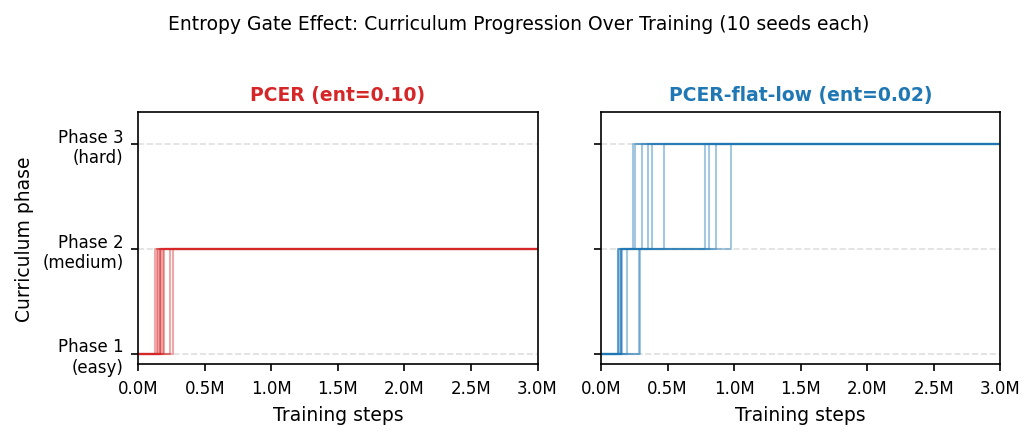

In [6]:
from IPython.display import Image
Image('phase_gate.png')

## 6. Sample Efficiency

In [7]:
TARGET = 200.0

print(f'Timesteps to first episode reward >= {TARGET}:')
print(f'{"Variant":<20} {"Mean":>10} {"Std":>10} {"Seeds reached":>15}')
print('-' * 60)

for variant, label, _ in VARIANTS:
    effs = []
    for seed in SEEDS:
        try:
            x, y = load_run(variant, seed)
            idx = np.argmax(y >= TARGET)
            if y[idx] >= TARGET:
                effs.append(int(x[idx]))
        except FileNotFoundError:
            pass
    if effs:
        print(f'{label:<20} {int(np.mean(effs)):>10,} {int(np.std(effs)):>10,} {len(effs):>10}/{len(SEEDS)}')
    else:
        print(f'{label:<20} {"never":>10}')

Timesteps to first episode reward >= 200.0:
Variant                    Mean        Std   Seeds reached
------------------------------------------------------------
Baseline                221,330     52,497         10/10
Baseline-low            181,064     44,626         10/10
Threshold               288,065    139,594         10/10
PCER-flat-low           183,078     53,077         10/10
